# Diagnosing Barren Plateaus in QML with PyQit

A "Barren Plateau" occurs when the gradient landscape of a quantum neural network becomes completely flat. If you try to train a model in a barren plateau, the optimizer has no signal to follow, and your model will never learn.

In this notebook, we will use `PyQit` to:
1. Build a deep, untrainable model and diagnose it manually.
2. Build a healthy model and use the automated `Trainer` check for barren plateau.

In [1]:
import numpy as np
from sklearn.datasets import make_moons

import pyqit
from pyqit.ansatzes.sel import SELAnsatz
from pyqit.core.embeddings import AngleEmbedding
from pyqit.core.trainer import Trainer
from pyqit.data.datamodule import DataModule
from pyqit.models.classification.vqc import VQCClassifier
from pyqit.utils.diagnostic import check_barren_plateau

# Set backend to lightning.qubit for faster simulations
pyqit.set_backend("pennylane")

INFO: Backend safely set to 'pennylane' for current context.


### 1. Preparing the Data
We will use a simple nonlinear classical dataset and wrap it in a `DataModule`.

In [2]:
# Generate a toy dataset
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
X_scaled = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) * np.pi
# Initialize the DataModule
dm = DataModule(
    X=X_scaled,
    y=y,
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
)

### 2. Standalone Diagnostic: The "Trap" Model
Let's build a model that is doomed to fail. We will use a relatively high number of qubits (8) and a very deep circuit (15 layers). According to McClean et al., this combination is highly likely to hit a barren plateau.

We will use the standalone `check_barren_plateau` function to visualize the gradient landscape *before* we waste time training.

INFO: Running Barren Plateau Diagnostic | Model: VQCClassifier | Backend: pennylane | Samples: 100


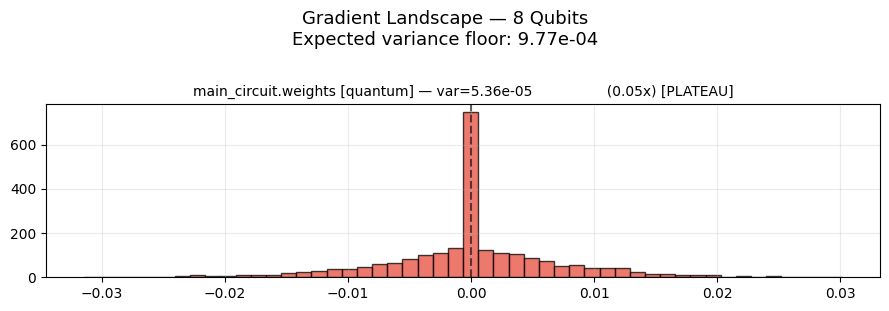


           BP Diagnostic Result : BARREN PLATEAU           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Metric / Layer              ┃    Value ┃         Status ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Qubits                      │        8 │                │
│ Samples                     │      100 │                │
│ Expected Variance           │ 9.77e-04 │       Baseline │
│ Quantum Variance            │ 5.36e-05 │ BARREN PLATEAU │
├─────────────────────────────┼──────────┼────────────────┤
│ Layer: main_circuit.weights │   0.055x │      ← plateau │
└─────────────────────────────┴──────────┴────────────────┘


In [3]:
# Create an untrainable, deep VQC
bad_model = VQCClassifier(
    n_qubits=8, n_layers=15, n_classes=2, ansatz=SELAnsatz, encoder=AngleEmbedding
)
dm.setup()  # Prepare dataloaders (required for diagnostics)

# Run the standalone diagnostic tool to check for barren plateaus
result = check_barren_plateau(
    model=bad_model,
    datamodule_or_X=dm,
    num_samples=100,  # 100 random weight initializations
    plot=True,
)

print(result)

*Notice how the variance is astronomically small, and the histogram looks like a single needle stuck at zero? The optimizer cannot navigate this landscape!*

---
### 3. Integrated Diagnostic: The "Healthy" Model
Now let's build a model with a shallower circuit (3 layers) and fewer qubits (4). 

Instead of running the diagnostic manually, we will let the `Trainer` do it automatically by passing `check_bp=True`. This is the recommended "Pre-Flight Check" for production pipelines.

In [4]:
pyqit.set_backend("torch")  # Trying a different backend for the "good" model
dm_new = DataModule(
    X=X_scaled,
    y=y,
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
)

INFO: Backend safely set to 'torch' for current context.


In [5]:
# Create a healthy, shallow VQC
good_model = VQCClassifier(
    n_qubits=4, n_layers=3, n_classes=2, ansatz=SELAnsatz, encoder=AngleEmbedding
)

# Initialize the Trainer with the check enabled
trainer = Trainer(
    max_epochs=5,
    learning_rate=0.05,
    check_bp=True,  # Automated Barren Plateau check!
    bp_samples=100,
    verbose=1,  # Set to 1 to see the rich tables
)

# Fit the model
# The trainer will automatically print the diagnostic table before Epoch 1 begins.
history = trainer.fit(good_model, datamodule=dm_new)

[Trainer]                         Starting torch backend |                              5 epochs | lr=0.05

INFO: Running Barren Plateau diagnostic...
INFO: Running Barren Plateau Diagnostic | Model: VQCClassifier | Backend: torch | Samples: 100
/home/aryan/PyQit/pyqit/utils/diagnostic.py:224: UserWarning: Using a target size (torch.Size([30])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = loss_fn(preds, y_t)
INFO: Model looks healthy. Variance is 1.2x above the random baseline.



           BP Diagnostic Result : HEALTHY            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric / Layer              ┃    Value ┃   Status ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ Qubits                      │        4 │          │
│ Samples                     │      100 │          │
│ Expected Variance           │ 1.56e-02 │ Baseline │
│ Quantum Variance            │ 1.91e-02 │  HEALTHY │
├─────────────────────────────┼──────────┼──────────┤
│ Layer: main_circuit.weights │   1.223x │  Healthy │
└─────────────────────────────┴──────────┴──────────┘


INFO: GPU available: True (cuda), used: False
INFO: GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: 
Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for 
val/test dataloaders.

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
